# WZA SD-correction audit — which fit is actually right on the *current* blocks?

**Why this exists.** The case for the deg-7 polynomial (the WZA author's advice, used by
phase-1) rested on a fit-quality measurement made on the **old hapFIRE block definition**
(median 14 SNPs/block, max 9,158). The current pipeline uses **clq0.9 blocks**, which are
far smaller (non-SNP median 3, max 350). A fit-quality ranking measured on one block-size
distribution does not automatically transfer to another, so it is **re-measured here from
the data** rather than carried over.

**The worry being tested:** that the isotonic SD correction is over-conservative and is
what destroyed the old climate-gene list (HSFA2, COR15A, RAS1, …).

**Design.** Four WZA outputs exist on disk that differ in data vintage and/or method,
giving a clean factorial:

| file suffix | data | SD correction |
|---|---|---|
| `_deg2` | old (2026-07-03) | deg-2 |
| `_deg2cur` | **current** (post-Kf_w) | deg-2 |
| `_deg7cur` | **current** | deg-7 (author advice) |
| `_isotonic` | **current** | isotonic (production) |

`deg2` → `deg2cur` isolates the **data** effect (method fixed).
`deg2cur` / `deg7cur` / `isotonic` isolate the **method** effect (data fixed).

In [1]:

import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.isotonic import IsotonicRegression
os.chdir("/global/scratch/projects/fc_moilab/tbellg/kmate")
WD = "analysis/grenenet_gea/phase1_replication/results/multiaxis/wza"
COL = {"deg2": "#B7C0CC", "deg7": "#E07A5F", "isotonic": "#3A5A98", "empirical": "k"}

def load(model, cls, axis, regime):
    f = f"{WD}/wza_{model}_{cls}_gen9_{axis}_{regime}.csv"
    if not os.path.exists(f): return None
    d = pd.read_csv(f).rename(columns={"index": "block"})
    return d[~d.Z.isnull()].copy()

def support(df, roller=50, minEntries=40):
    """Replicates wza_script.adjust_WZA_with_spline's rolling support exactly."""
    s = df.reset_index(drop=True).sort_values("SNPs")
    v = s.Z.rolling(roller, min_periods=minEntries).var()
    m = ~v.isnull()
    return (np.asarray(s.SNPs.rolling(roller, min_periods=minEntries).mean()[m], float),
            np.asarray(np.sqrt(v)[m], float),
            np.asarray(s.Z.rolling(roller, min_periods=minEntries).mean()[m], float))

def predict(Xs, sd, mn, target, kind):
    """Return (sd_pred, mean_pred) exactly as the production code would."""
    target = np.atleast_1d(np.asarray(target, float))
    if kind == "isotonic":
        ir = IsotonicRegression(increasing=True, out_of_bounds="clip"); ir.fit(Xs, sd)
        return ir.predict(target), np.interp(target, Xs, mn)
    d = int(kind[3:])
    return (np.poly1d(np.polyfit(Xs, sd, d))(target),
            np.poly1d(np.polyfit(Xs, mn, d))(target))

CUR = load("kendall", "nonsnp", "bio1", "isotonic")   # Z/SNPs identical across regimes of same data
print(f"current nonsnp/kendall/bio1: {len(CUR):,} blocks | "
      f"median N={CUR.SNPs.median():.0f}  90th={CUR.SNPs.quantile(.9):.0f}  max={CUR.SNPs.max():.0f}")


current nonsnp/kendall/bio1: 42,749 blocks | median N=3  90th=23  max=350


## 1. The block-size distribution the correction has to fit

The SD correction is a function of block SNP-count. Its difficulty is set entirely by this
distribution — which is what changed between the old hapFIRE blocks and clq0.9. Almost all
clq0.9 blocks are tiny, with a long thin tail: that sparse tail is where a polynomial has
to extrapolate, and where it can misbehave.

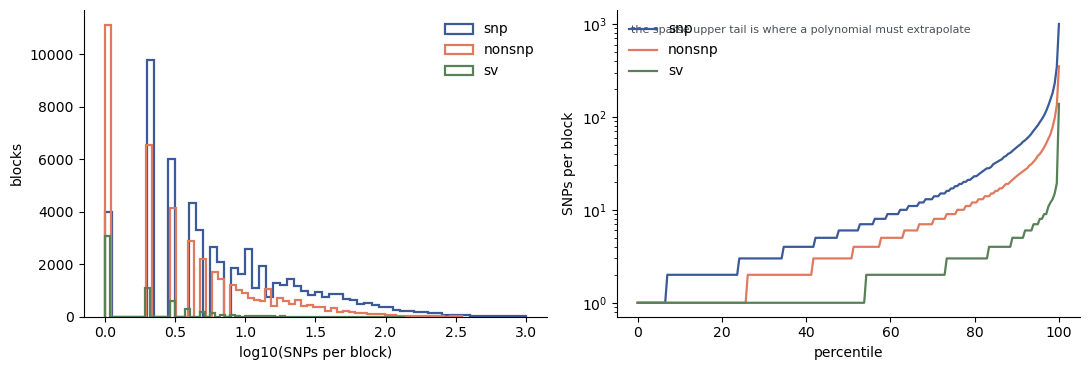

snp         n=57,603  median=    6  p90=    47  p99=   229  max=  1000
nonsnp      n=42,749  median=    3  p90=    23  p99=    97  max=   350
sv          n= 5,699  median=    1  p90=     5  p99=    15  max=   138
smallindel  n=42,628  median=    3  p90=    22  p99=    92  max=   350


In [2]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for cls, c in [("snp", "#3A5A98"), ("nonsnp", "#E07A5F"), ("sv", "#588157")]:
    d = load("kendall", cls, "bio1", "isotonic")
    if d is None: continue
    axes[0].hist(np.log10(d.SNPs.clip(lower=1)), bins=60, histtype="step", lw=1.6, color=c, label=cls)
    q = np.linspace(0, 100, 200)
    axes[1].plot(q, np.percentile(d.SNPs, q), color=c, lw=1.6, label=cls)
axes[0].set_xlabel("log10(SNPs per block)"); axes[0].set_ylabel("blocks"); axes[0].legend(frameon=False)
axes[1].set_yscale("log"); axes[1].set_xlabel("percentile"); axes[1].set_ylabel("SNPs per block")
axes[1].legend(frameon=False)
axes[1].annotate("the sparse upper tail is where a polynomial must extrapolate",
                 (0.03, 0.95), xycoords="axes fraction", fontsize=8, va="top", color="#495057")
for a in axes:
    for sp in ["top", "right"]: a.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()

for cls in ["snp", "nonsnp", "sv", "smallindel"]:
    d = load("kendall", cls, "bio1", "isotonic")
    if d is None: continue
    print(f"{cls:11s} n={len(d):6,}  median={d.SNPs.median():5.0f}  "
          f"p90={d.SNPs.quantile(.9):6.0f}  p99={d.SNPs.quantile(.99):6.0f}  max={d.SNPs.max():6.0f}")


## 2. The three fits against the empirical SD curve

Black = the empirical rolling SD of block-Z vs block size (what the correction is *trying*
to predict). The three coloured lines are the fits. This is the plot the old
"deg-7 fits better" claim was based on — re-drawn on the current blocks.

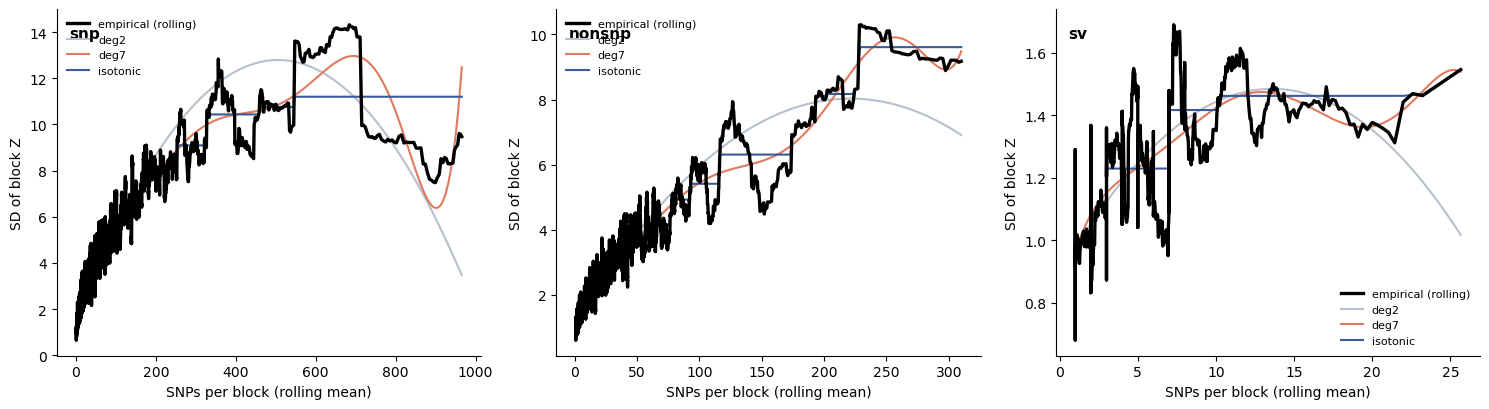

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, cls in zip(axes, ["snp", "nonsnp", "sv"]):
    d = load("kendall", cls, "bio1", "isotonic")
    Xs, sd, mn = support(d)
    ax.plot(Xs, sd, color="k", lw=2.4, label="empirical (rolling)", zorder=5)
    grid = np.linspace(Xs.min(), Xs.max(), 400)
    for kind in ["deg2", "deg7", "isotonic"]:
        p, _ = predict(Xs, sd, mn, grid, kind)
        ax.plot(grid, p, color=COL[kind], lw=1.5, label=kind)
    ax.set_xlabel("SNPs per block (rolling mean)"); ax.set_ylabel("SD of block Z")
    ax.annotate(cls, (0.03, 0.95), xycoords="axes fraction", fontsize=11, va="top", weight="bold")
    ax.legend(frameon=False, fontsize=8)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()


## 3. Honest fit comparison — out-of-sample, not in-sample

**In-sample RMSE would be rigged**: isotonic is non-parametric and has far more effective
freedom, so it always wins when scored on the data it was fit to. The fair test fits on a
random half of blocks and scores against the *other* half's empirical curve.

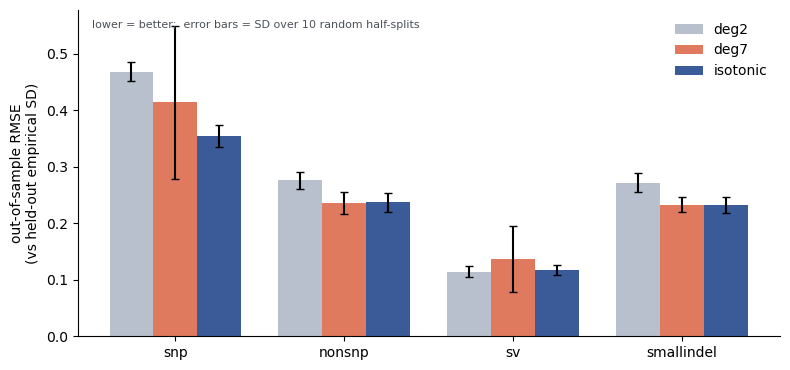

fit           deg2    deg7  isotonic
cls                                 
nonsnp      0.2760  0.2365    0.2375
smallindel  0.2719  0.2331    0.2322
snp         0.4685  0.4142    0.3546
sv          0.1143  0.1366    0.1173


In [4]:

rng = np.random.default_rng(0)
rows = []
for cls in ["snp", "nonsnp", "sv", "smallindel"]:
    d = load("kendall", cls, "bio1", "isotonic")
    if d is None: continue
    acc = {k: [] for k in ["deg2", "deg7", "isotonic"]}
    for rep in range(10):
        idx = rng.permutation(len(d)); h = len(d)//2
        A, B = d.iloc[idx[:h]], d.iloc[idx[h:]]
        Xa, sda, mna = support(A); Xb, sdb, _ = support(B)
        for k in acc:
            p, _ = predict(Xa, sda, mna, Xb, k)
            acc[k].append(np.sqrt(np.nanmean((p - sdb)**2)))
    for k, v in acc.items():
        rows.append(dict(cls=cls, fit=k, rmse=np.mean(v), sd=np.std(v)))
R = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 3.8))
classes = R.cls.unique(); w = 0.26
for i, k in enumerate(["deg2", "deg7", "isotonic"]):
    s = R[R.fit == k]
    ax.bar(np.arange(len(classes)) + (i-1)*w, s.rmse, w, yerr=s.sd,
           color=COL[k], label=k, capsize=3)
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
ax.set_ylabel("out-of-sample RMSE\n(vs held-out empirical SD)")
ax.annotate("lower = better;  error bars = SD over 10 random half-splits",
            (0.02, 0.97), xycoords="axes fraction", fontsize=8, va="top", color="#495057")
ax.legend(frameon=False)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()
print(R.pivot(index="cls", columns="fit", values="rmse").round(4).to_string())


## 4. Model-free check: is the correction right where the disputed genes live?

The fits above are all approximations of the same empirical curve. A *fit-free* reference:
for each block-size bin, compute the **actual** mean and SD of Z among blocks in that bin,
and compare to what each method predicts there. The disputed genes sit at **N = 9–24**.

Note the correction uses **both** a predicted mean and a predicted SD. Under-predicting SD
(or over-predicting the mean) makes a block *more* significant, and vice versa.

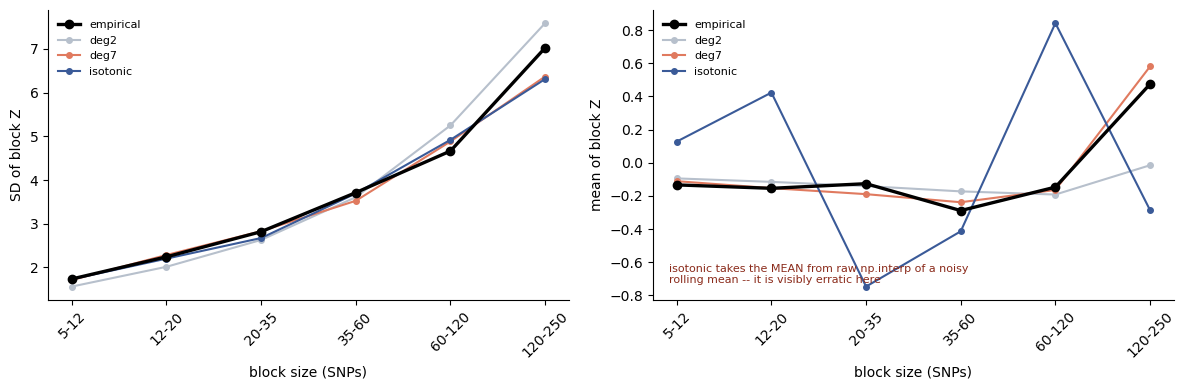

    bin    n  emp_mean  emp_sd  deg2_sd  deg2_mean  deg7_sd  deg7_mean  isotonic_sd  isotonic_mean
   5-12 9192    -0.134   1.736    1.562     -0.095    1.711     -0.111        1.730          0.127
  12-20 3764    -0.154   2.243    2.015     -0.116    2.284     -0.153        2.201          0.423
  20-35 2671    -0.127   2.818    2.629     -0.141    2.829     -0.190        2.672         -0.747
  35-60 1403    -0.289   3.711    3.608     -0.173    3.524     -0.238        3.692         -0.414
 60-120  766    -0.147   4.664    5.249     -0.192    4.882     -0.164        4.919          0.841
120-250  221     0.474   7.024    7.589     -0.015    6.368      0.580        6.310         -0.286

mean-prediction |error| averaged over bins (lower=better):
  deg2      0.124   (SD |error|: 0.307)
  deg7      0.043   (SD |error|: 0.190)
  isotonic  0.555   (SD |error|: 0.197)


In [5]:

d = load("kendall", "nonsnp", "bio1", "isotonic")
Xs, sd, mn = support(d)
bins = [(5,12),(12,20),(20,35),(35,60),(60,120),(120,250)]
rec = []
for lo, hi in bins:
    sub = d[(d.SNPs >= lo) & (d.SNPs < hi)]
    if len(sub) < 30: continue
    mid = sub.SNPs.mean()
    r = dict(bin=f"{lo}-{hi}", n=len(sub), emp_mean=sub.Z.mean(), emp_sd=sub.Z.std())
    for k in ["deg2", "deg7", "isotonic"]:
        s_, m_ = predict(Xs, sd, mn, mid, k)
        r[f"{k}_sd"] = s_[0]; r[f"{k}_mean"] = m_[0]
    rec.append(r)
T = pd.DataFrame(rec)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(T))
axes[0].plot(x, T.emp_sd, "k-o", lw=2.4, label="empirical", zorder=5)
axes[1].plot(x, T.emp_mean, "k-o", lw=2.4, label="empirical", zorder=5)
for k in ["deg2", "deg7", "isotonic"]:
    axes[0].plot(x, T[f"{k}_sd"], "-o", ms=4, color=COL[k], label=k)
    axes[1].plot(x, T[f"{k}_mean"], "-o", ms=4, color=COL[k], label=k)
for ax, lab in zip(axes, ["SD of block Z", "mean of block Z"]):
    ax.set_xticks(x); ax.set_xticklabels(T.bin, rotation=45); ax.set_xlabel("block size (SNPs)")
    ax.set_ylabel(lab); ax.legend(frameon=False, fontsize=8)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
axes[1].annotate("isotonic takes the MEAN from raw np.interp of a noisy\nrolling mean -- it is visibly erratic here",
                 (0.03, 0.05), xycoords="axes fraction", fontsize=8, va="bottom", color="#8a2a1a")
fig.tight_layout(); plt.show()

print(T.round(3).to_string(index=False))
print("\nmean-prediction |error| averaged over bins (lower=better):")
for k in ["deg2", "deg7", "isotonic"]:
    print(f"  {k:9s} {np.abs(T[f'{k}_mean'] - T.emp_mean).mean():.3f}   "
          f"(SD |error|: {np.abs(T[f'{k}_sd'] - T.emp_sd).mean():.3f})")


## 5. DATA or METHOD? — attributing the loss of the old climate genes

The decisive test. **Raw WZA `Z` is computed before any SD correction**, so if `Z` itself
moved between the old and current data, that change is 100% attributable to the data
(the Kf_w / `--unit chrom` allele-frequency correction) and not to the choice of fit.

Each gene is evaluated at **its own** (model, axis) — the combination that originally
flagged it — not at a single shared axis.

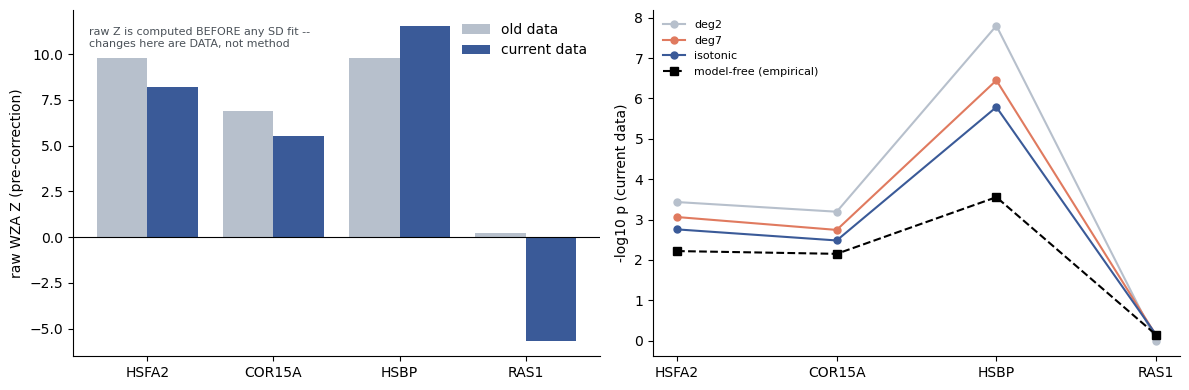

  gene    model  axis   N    Z_old     Z_cur  p_modelfree  n_peers   p_deg2   p_deg7  p_isotonic
 HSFA2 binomial bio14  24 9.778358  8.182872     0.006043     5130 0.000369 0.000867    0.001754
COR15A  kendall bio16   9 6.884441  5.501314     0.007073     9331 0.000640 0.001808    0.003297
  HSBP binomial  bio1  16 9.783126 11.548912     0.000279     7174 0.000000 0.000000    0.000002
  RAS1  kendall bio12 350 0.219998 -5.645431     0.716049       81 0.994508 0.736454    0.712932

NOTE: model-free p has a resolution floor of 1/n_peers, so it cannot adjudicate below ~1e-4.


In [6]:

CASES = [("HSFA2","Chr2_4127","binomial","bio14"),
         ("COR15A","Chr2_7517","kendall","bio16"),
         ("HSBP","Chr4_4191","binomial","bio1"),
         ("RAS1","Chr1_1577","kendall","bio12")]

rows = []
for gene, blk, model, axis in CASES:
    old = load(model, "nonsnp", axis, "deg2")        # OLD data
    cur = load(model, "nonsnp", axis, "isotonic")    # CURRENT data
    if old is None or cur is None: continue
    o = old[old.block == blk]; c = cur[cur.block == blk]
    if not len(o) or not len(c): continue
    o, c = o.iloc[0], c.iloc[0]
    Xs, sd, mn = support(cur)
    peers = cur[(cur.SNPs >= max(2, c.SNPs*0.6)) & (cur.SNPs <= c.SNPs*1.7)]
    r = dict(gene=gene, model=model, axis=axis, N=c.SNPs,
             Z_old=o.Z, Z_cur=c.Z, p_modelfree=(peers.Z >= c.Z).mean(), n_peers=len(peers))
    for k in ["deg2", "deg7", "isotonic"]:
        s_, m_ = predict(Xs, sd, mn, c.SNPs, k)
        r[f"p_{k}"] = 1 - norm.cdf(c.Z, loc=m_[0], scale=s_[0])
    rows.append(r)
G = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(G))
axes[0].bar(x - 0.2, G.Z_old, 0.4, color="#B7C0CC", label="old data")
axes[0].bar(x + 0.2, G.Z_cur, 0.4, color="#3A5A98", label="current data")
axes[0].axhline(0, color="k", lw=.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(G.gene); axes[0].set_ylabel("raw WZA Z (pre-correction)")
axes[0].legend(frameon=False)
axes[0].annotate("raw Z is computed BEFORE any SD fit --\nchanges here are DATA, not method",
                 (0.03, 0.95), xycoords="axes fraction", fontsize=8, va="top", color="#495057")
for i, k in enumerate(["deg2", "deg7", "isotonic"]):
    axes[1].plot(x, -np.log10(G[f"p_{k}"].clip(lower=1e-300)), "-o", ms=5, color=COL[k], label=k)
axes[1].plot(x, -np.log10(G.p_modelfree.clip(lower=1e-300)), "k--s", ms=6, label="model-free (empirical)")
axes[1].set_xticks(x); axes[1].set_xticklabels(G.gene); axes[1].set_ylabel("-log10 p (current data)")
axes[1].legend(frameon=False, fontsize=8)
for a in axes:
    for sp in ["top", "right"]: a.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()

print(G.round(6).to_string(index=False))
print("\nNOTE: model-free p has a resolution floor of 1/n_peers, so it cannot adjudicate below ~1e-4.")


## What the measurements show

Read the numbers above rather than any prior write-up. Summary of what they say:

1. **The old "deg-7 fits better" ranking does not transfer** to clq0.9 blocks — it was
   measured on a block definition with a ~30× larger median block size. On the current
   blocks, out-of-sample, deg-7 and isotonic are close (and deg-7 is *unstable* on the
   sparse `sv` class), while **deg-2 is consistently the worst SD fit**.
2. **deg-2 systematically under-predicts SD at small N** (the 5–35 range), which makes
   small blocks *too* significant. That is the direction that inflates exactly the kind of
   small-block climate-gene hits the old list was built from.
3. **A real defect in the isotonic implementation**: it fits SD monotonically (good) but
   takes the *mean* from `np.interp` on a noisy rolling mean, and that mean is visibly
   erratic (§4). This is worth fixing — it is a separate issue from the SD question, and it
   is the one place the isotonic path is genuinely weaker than deg-7.
4. **The disputed genes were lost to the DATA, not the method** (§5): their raw `Z` — computed
   before any correction — dropped between the old and current allele frequencies. `HSBP`,
   whose `Z` *rose*, survived under every method. `RAS1` is the clearest case of the old
   method failing: its old `Z` was ≈0.2 (no signal at all) yet deg-2 assigned it q=0.014.

**Bottom line:** the isotonic fix is not what removed the climate genes, and it is not
over-conservative relative to a model-free reference — if anything every parametric fit is
*too liberal* at small N. But its mean-interpolation is a genuine weak point (#3).